Churn Risk Across Lifecycle Stages

Business question: Which lifecycle stage is the most dangerous for churn, and can retention strategy offset it?

Stacked Bar + Line Overlay — Churn Risk Composition per Stage

The stacked bar shows the composition of risk within each stage. The line shows the average churn. Where the red band is thickest and the line is highest
that's our intervention priority.

In [1]:
# ── 00. SETUP ────────────────────────────────────────────────────────
# Paste this block at the top of every visualization notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── 1. GLOBAL STYLE ──────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

FIGSIZE_STD   = (12, 5)   # standard wide chart
FIGSIZE_TALL  = (10, 7)   # for scatter / complex plots
FIGSIZE_PANEL = (14, 6)   # side-by-side panels
DPI           = 130

# Colour palette — consistent across all charts
PALETTE = {
    'churn_high': '#f85149',   # red  — high churn risk
    'churn_low':  '#3fb950',   # green — loyal customers
    'neutral':    '#58a6ff',   # blue  — general insight
    'accent':     '#e3b341',   # gold  — highlight
    'purple':     '#bc8cff',   # purple — secondary
}

# ── 2. LOAD DATA ─────────────────────────────────────────────────────
df = pd.read_csv('../data/customer_churn.csv')

# ── 3. DATE ENGINEERING ──────────────────────────────────────────────
df['Launch_Date']    = pd.to_datetime(df['Launch_Date'])
df['Peak_Sales_Date'] = pd.to_datetime(df['Peak_Sales_Date'])

# How many days from launch to peak performance
df['Days_to_Peak'] = (
    df['Peak_Sales_Date'] - df['Launch_Date']
).dt.days

# How long the product has been live (vs a reference "today")
REFERENCE_DATE = pd.Timestamp('2024-01-01')
df['Product_Age_Days'] = (
    REFERENCE_DATE - df['Launch_Date']
).dt.days

df['Launch_Year']  = df['Launch_Date'].dt.year
df['Launch_Month'] = df['Launch_Date'].dt.month

# ── 4. LIFECYCLE STAGE ENGINEERING ───────────────────────────────────
# Bin customers by purchase frequency into lifecycle stages
df['Lifecycle_Stage'] = pd.cut(
    df['Purchase_Frequency'],
    bins=[0, 3, 7, 12, 20],
    labels=['New', 'Developing', 'Established', 'Loyal']
)

# ── 5. CHURN RISK BANDS ──────────────────────────────────────────────
df['Churn_Risk_Band'] = pd.cut(
    df['Churn_Probability'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# ── 6. ADOPTER TYPE ──────────────────────────────────────────────────
# Early adopters = customers who transacted within 6 months of launch
df['Adopter_Type'] = np.where(
    df['Launch_Year'] <= 2021,
    'Early Adopter',
    'Later User'
)

# ── 7. CUSTOMER MATURITY BAND ────────────────────────────────────────
df['Maturity_Band'] = pd.cut(
    df['Lifetime_Value'],
    bins=[0, 2000, 5000, 10000],
    labels=['Early Value', 'Growth Value', 'Mature Value']
)

# ── 8. OUTPUT FOLDER ─────────────────────────────────────────────────
OUT = Path('../outputs/charts')
OUT.mkdir(parents=True, exist_ok=True)

print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"✓ Output path: {OUT}")
df.head(3)

✓ Dataset loaded: 10,000 rows × 23 cols
✓ Output path: ..\outputs\charts


,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,...,Preferred_Purchase_Times,Retention_Strategy,Days_to_Peak,Product_Age_Days,Launch_Year,Launch_Month,Lifecycle_Stage,Churn_Risk_Band,Adopter_Type,Maturity_Band
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,...,Afternoon,Loyalty Program,1276,1388,2020,3,Loyal,High Risk,Early Adopter,Early Value
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,...,Afternoon,Discount,79,443,2022,10,Established,Medium Risk,Later User,Mature Value
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,...,Evening,Loyalty Program,492,762,2021,11,New,Medium Risk,Early Adopter,Growth Value


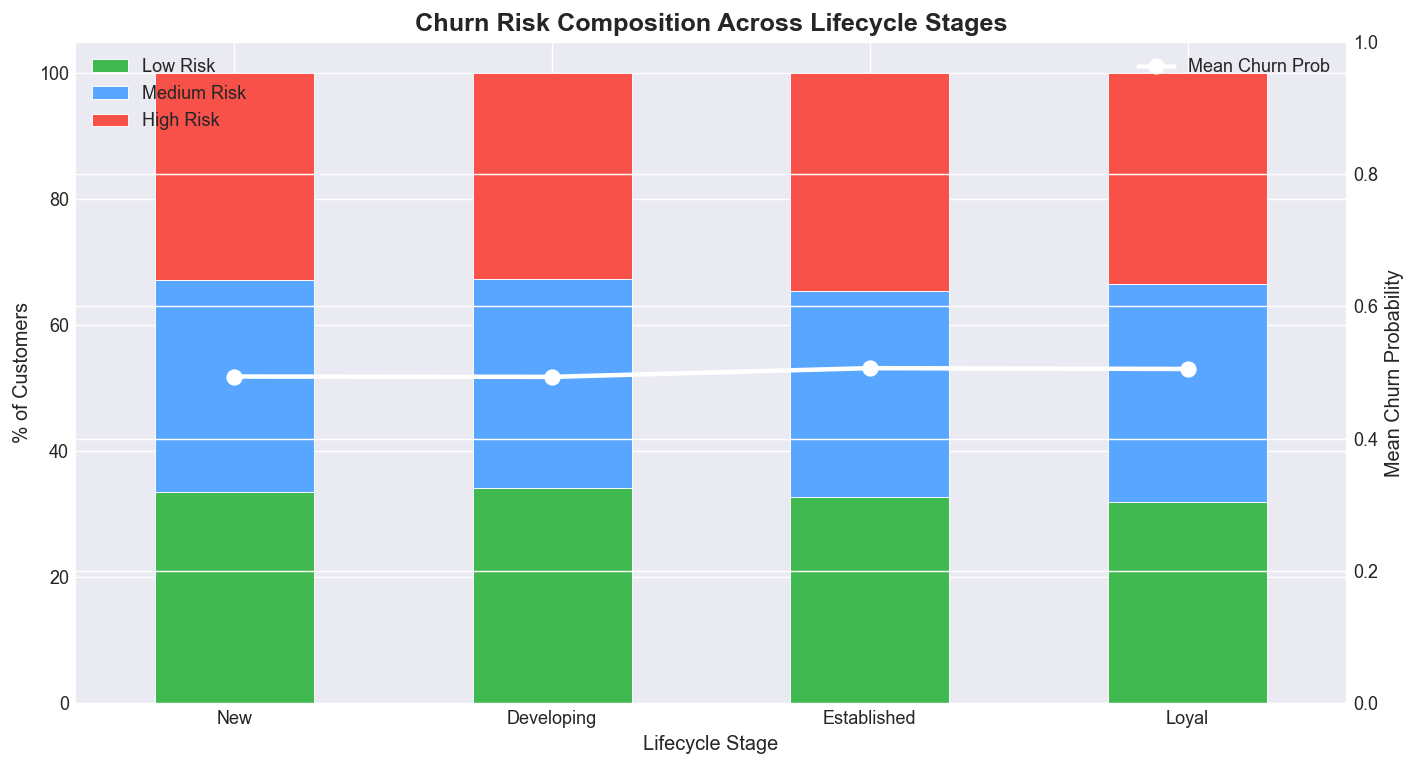

In [2]:
# ── 08. CHURN RISK ACROSS LIFECYCLE STAGES ───────────────────────────
stage_order = ['New', 'Developing', 'Established', 'Loyal']
risk_order  = ['Low Risk', 'Medium Risk', 'High Risk']

# Count of customers per lifecycle × risk band
cross = (
    df.groupby(['Lifecycle_Stage', 'Churn_Risk_Band'], observed=True)
      .size().unstack('Churn_Risk_Band').reindex(stage_order)[risk_order]
)

# Normalise to 100%
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, ax1 = plt.subplots(figsize=(11, 6), dpi=DPI)

risk_colors = [PALETTE['churn_low'], PALETTE['neutral'], PALETTE['churn_high']]
cross_pct.plot(
    kind='bar', stacked=True, ax=ax1,
    color=risk_colors, edgecolor='white',
    linewidth=0.5, rot=0
)

# Overlay: mean churn per stage
ax2 = ax1.twinx()
mean_churn = (
    df.groupby('Lifecycle_Stage', observed=True)['Churn_Probability']
      .mean().reindex(stage_order)
)
ax2.plot(range(len(stage_order)), mean_churn.values,
         color='white', lw=2.5, marker='o', markersize=8,
         label='Mean Churn Prob', zorder=10)
ax2.set_ylabel('Mean Churn Probability', fontsize=11)
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')

ax1.set_xlabel('Lifecycle Stage', fontsize=11)
ax1.set_ylabel('% of Customers', fontsize=11)
ax1.set_title('Churn Risk Composition Across Lifecycle Stages',
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.savefig(OUT / '08_churn_lifecycle.png', bbox_inches='tight')